# LAB 2: Prognosis and survival functions

In this lab, we will analyze observations from different ovarian cancer patients and we will create different survival functions employing univariate (Kaplan-Meier estimate) and multivariate (CPH and Extra Survival Trees) analysis.

Remember to copy this notebook into your own drive and your JHED ID as suffix (It's the part before the @ symbol in your email, not your Hopkins ID in the SIS):


*   eg: Lab2_Prognosis_myjhedID

Please always remember to use the MLMA coding rubric.

In [1]:
# Install the package you need for this lab
# You may need to install them every time you restart the runtime
!pip install lifelines
!pip install xlrd
!pip install scikit-survival

In [2]:
# Feel free to add more libraries if you need them
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sksurv.ensemble import ExtraSurvivalTrees
from sksurv.preprocessing import OneHotEncoder
import xlrd
import zipfile

**DATA**

The data that we are going to use in this lab is a subset of the data described in the paper ["Gene Expression Profile for Predicting Survival in Advanced-Stage Serous Ovarian Cancer Across Two
Independent Datasets"](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0009615). According to the authors:

>One hundred ten Japanese patients who were diagnosed with advanced-stage serous ovarian cancer between July 1997 and June 2008 were included in this study. Fresh-frozen samples were obtained from primary tumor tissues during primary debulking surgery prior to chemotherapy. [...] frozen tissues containing more than 80% of tumor cells upon histological evaluation were used for RNA extraction. [...] Optimal debulking surgery was defined as ≤ 1cm of gross residual disease. [...] Overall survival time was calculated as the interval from primary surgery to the death due to ovarian cancer.

For our purposes, we are going to consider time-to-death, debulking optimality, and five biomarker genes associated with ovarian cancer survival (CXCL12, NCOA3, PDPN, TEAD1, YWHAB).

In [3]:
# Load the data (adjust path if necessary)
df=pd.read_csv('./data.csv')

df.head()

,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
0,GSM432220,1650,0,0,-0.526989,1.305942,0.144564
1,GSM432221,30,1,1,-0.180496,1.286216,-0.455337
2,GSM432222,720,0,1,0.747367,-1.369031,0.626061
3,GSM432223,780,0,1,-0.425558,1.613270,0.458312
4,GSM432224,990,1,1,-0.476626,0.611514,-0.218782


In [4]:
# Visualize the data and obtain statistics (number of observations and predictor variables)
print('Number of observations: ', len(df))
print('Number of predictor variables: ', len(df.columns)-1)
df.head()

Number of observations:  84
Number of predictor variables:  6


,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
0,GSM432220,1650,0,0,-0.526989,1.305942,0.144564
1,GSM432221,30,1,1,-0.180496,1.286216,-0.455337
2,GSM432222,720,0,1,0.747367,-1.369031,0.626061
3,GSM432223,780,0,1,-0.425558,1.613270,0.458312
4,GSM432224,990,1,1,-0.476626,0.611514,-0.218782


## Task 1. Check your data (3 POINTS)
---
Please check the debulking optimality and CXCL12 gene expression distributions of the dataset

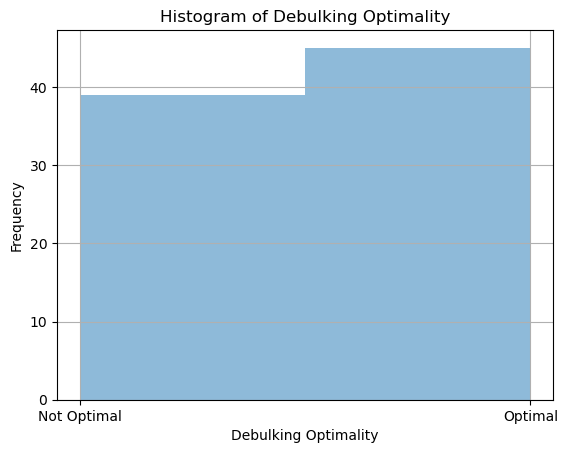

Number of patients expressing NCOA3 gene (NCOA3 > 0): 40


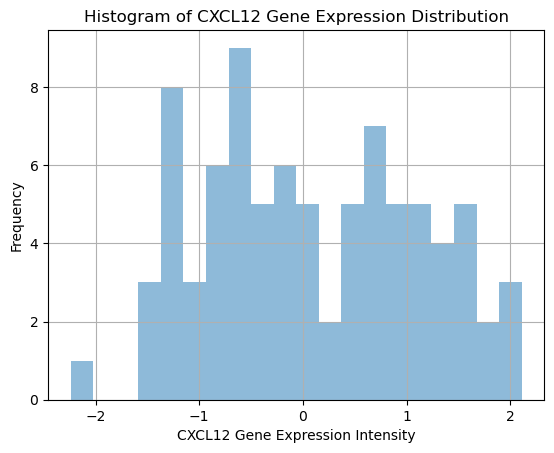

In [5]:
# Please plot a histogram of the debulking optimality distribution:
# debulk:0 - not optimal
# debulk:1 - optimal

# YOUR CODE GOES HERE
df.hist(column='debulk', bins=2, alpha=0.5)
plt.xlabel('Debulking Optimality')
plt.ylabel('Frequency')
plt.title('Histogram of Debulking Optimality')
plt.xticks([0, 1], ['Not Optimal', 'Optimal'])
plt.show()

# and answer a question briefly：how many patients in this dataset expressed the NCOA3 gene (NCOA3>0)?
print(f"Number of patients expressing NCOA3 gene (NCOA3 > 0): {len(df[df['NCOA3'] > 0])}")
# Please plot a histogram of the CXCL12 gene expression distribution:
# The numeric values represent a patient's gene expression intensity, with high values indicating high levels of expression.
df.hist(column='CXCL12', bins=20, alpha=0.5)
plt.xlabel('CXCL12 Gene Expression Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of CXCL12 Gene Expression Distribution')
plt.show()
# YOUR CODE GOES HERE

## Task 2 (2 POINT)
---
Do you think the dataset we are using is balanced in terms of CXCL12 gene expression? Why or why not?

Answer:

I wouldn't say so that the data is fairly distributed intearms of the CXCL12 gene expression because of about 1.5 seem a bit over represented according to the histogram. If the dataset is balanced then we would expect the histogram to look somewhat uniform. 

# 1. Prognostic Model

Different from survival models, prognostic models try to answer questions referred to fixed period or related to a certain event.

In [6]:
df.head()

,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3
0,GSM432220,1650,0,0,-0.526989,1.305942,0.144564
1,GSM432221,30,1,1,-0.180496,1.286216,-0.455337
2,GSM432222,720,0,1,0.747367,-1.369031,0.626061
3,GSM432223,780,0,1,-0.425558,1.613270,0.458312
4,GSM432224,990,1,1,-0.476626,0.611514,-0.218782


In [7]:
print(df[df["ID"] == "GSM432223" ])

          ID  time  death  debulk   ANKRD27   CXCL12     NCOA3
3  GSM432223   780      0       1 -0.425558  1.61327  0.458312


## TASK 3 (4 POINTS)
---
The maximum follow-up time for patients in was 2430 days. Answer the following quesitons briefly (without repeating any answers).

1. Patient GSM432223 is listed as having time = 60 days and death = 0. What is a potential conclusion you can draw about their outcome?

Answer:

It means that patient GSM432223 is censored. Meaning they were part of the data collection program until day 60 but after that they dropped it. We can not conclude any further about weather they survived or died after the 60th day. 

In [8]:
print(df[df["ID"] == "GSM432229" ])

          ID  time  death  debulk   ANKRD27    CXCL12     NCOA3
8  GSM432229  1710      1       1 -0.262738  0.373057 -1.372724


2. Patient GSM432229 is listed as having time = 1710 days and death = 1. What is a potential conclusion you can draw about their outcome?

Answer:

It means that the patient died in the 1710th day of being in the program.

3. Patient GSM432307 is listed as having time = 2430 days and death = 0. What is a potential conclusion you can draw about their outcome?

Answer:

This means that the patient survived through out the program and didn't die. We would still consider the patient to be censored after the 2430th day because no further studies were conducted.

4. Assuming that your conclusions are all true, which one of the above patients is considered censored?

Patient GSM432307 and Patient GSM432223 would be considered censored. Although patient GSM432307 didn't die through out the program we would still have to consider their data as censored after the 2430 days if we wanted to make any predictions but since we do not have any more data we wouldn't be able to make any kind of predictoins.

Answer:

## TASK 4 (2 POINTS)
---
To build a prognostic model (for instance, a model that predicts if someone will die at or before 90 days after surgical intervention for ovarian cancer), we should always delete all or part of the censored data. Briefly expain why this is necessary.

Answer:

To build a binary classification model that predicts if someone is going to survive or die by day 90 we would need to have a solid outcome label for every data instance in the dataset. That is because when fitting a regression model or decision tree model, the model is going to expect all rows to have a vaild label (0 or 1). If we have a censored data then we are at a superpostion state (like Schrödinger's cat) because we wouldn't now if the patient survied or not.

# 2. Univariate analysis: Univariate survival functions and cumulative hazard

## TASK 5 (5 POINTS)

What is the probablity of a patient being alive after 1500 days? i.e. Calculate $P_s(1500)$

In [9]:
# YOUR CODE GOES HERE
# 
filterd_data = df[(df["time"] > 1500) | (df["death"] == 1)]
print(filterd_data.head())

          ID  time  death  debulk   ANKRD27    CXCL12     NCOA3
0  GSM432220  1650      0       0 -0.526989  1.305942  0.144564
1  GSM432221    30      1       1 -0.180496  1.286216 -0.455337
4  GSM432224   990      1       1 -0.476626  0.611514 -0.218782
5  GSM432226   600      1       1  0.227868  0.408670 -1.137359
7  GSM432228  1800      0       1 -1.082229 -0.927825 -2.309780


In [10]:
print(f"Propbability of surviving more than 1500 days: {len(filterd_data[filterd_data['time'] > 1500]) / len(filterd_data)}")

Propbability of surviving more than 1500 days: 0.4117647058823529


## TASK 6 (10 POINTS)
---

Calculate and plot the survival function employing the Kaplan-Meier estimate  

In [11]:
# Calculate and plot the survival function employing the Kaplan-Meier estimate
def calculate_survival_KM(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
  """
Generates a dataframe containing the survival function (time vs probability of survival)
employing the Kaplan-Meier estimate.
Inputs:
      df: input dataframe
      TimeColumn: name of the colum containing the event time
      EventColumn: name of the column indicating if the event happened HAPPEN_INDICATOR or not NOT_HAPPEN_INDICATOR
      EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
      EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for alive
Outputs:
      dfSurv: dataframe containing the time and probability of survival
  """
  sorted_time_column = df[TimeColumn].sort_values().unique()
  dfSurv = pd.DataFrame({TimeColumn: sorted_time_column, 'Survival_Probability': np.ones(len(sorted_time_column))})
  previous_filtered_data = df

  # Initialize the starting probability
  previous_survival_prob = 1.0
  
  for index, time in enumerate(sorted_time_column):
    if time < 0:
      raise ValueError("Time cannot be negative.")
    
    len_people_at_risk = len(previous_filtered_data)
    if len_people_at_risk == 0:
      break # No more people at risk, stop the loop
    
    len_people_event_happen = len(previous_filtered_data[(previous_filtered_data[TimeColumn] == time) & (previous_filtered_data[EventColumn] == EVENT_HAPPEN_INDICATOR)])

    # Dynamic Programming: Calculate current probability using the tracker variable
    current_survival_prob = previous_survival_prob * (1 - (len_people_event_happen / len_people_at_risk))
    
    # Store it in the dataframe
    dfSurv.iloc[index, 1] = current_survival_prob
    
    # Update the tracker variable for the next loop
    previous_survival_prob = current_survival_prob
    
    # Update the at-risk pool for the next loop
    previous_filtered_data = previous_filtered_data[previous_filtered_data[TimeColumn] > time]

  return dfSurv


def plot_survival(df, TimeColumn, EventColumn, Name, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
  """
  This function plots the survival function of the whole df. This function calls
  calculate_survival_KM.
  Inputs:
      df: input dataframe
      TimeColumn: name of the colum containing the event time
      EventColumn: name of the column indicating if the event happened (1) or not (0)
      Name: legend to display, associated to the survival function
      EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
      EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for alive

  """
  dfSurv = calculate_survival_KM(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR)
  plt.step(dfSurv[TimeColumn], dfSurv['Survival_Probability'], where="post", label=Name)
  plt.xlabel('Time')
  plt.ylabel('Survival Probability')
  plt.title('Kaplan-Meier Survival Function')
  plt.legend()
  plt.grid()
  plt.show()
  # YOUR CODE GOES HERE

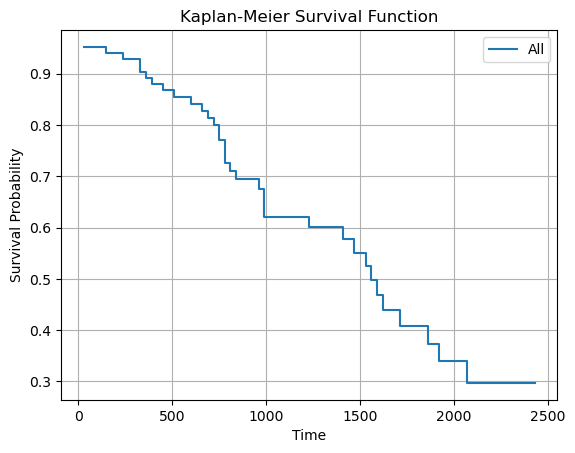

In [12]:
# Plot the survival function obtained with the entire dataframe
TimeColumn='time'
EventColumn='death'
plot_survival(df, TimeColumn, EventColumn, 'All', 1, 0)

## TASK 7 (10 POINTS)
---
Code a function that displays the survival function of two categories of a certain predictor (e.g. ANKRD27 expression > 0 vs. ANKRD27 expression ≤ 0) in the same plot.

In [13]:
# function to print two categories
def plot_survival_twocat(df, predictor, cat1, cat0,cat1_name, cat0_name ):
      """ Displays the survival function of two categories of a certain predictor
      (eg. optimal vs. nonoptimal debulking, NCOA3 expression > 1 vs. NCOA3 expression ≤ 1) in the same plot. This function
      only considers binary categories: 0 and 1.
      Inputs:
            df: input dataframe
            predictor: column containing the predictor variable that we want to study
            cat1: Label of the category associated to one category (eg. '0')
            cat0: Label of the category associated to the other category (eg. '1')
            cat1_name: Name for cat1's label (eg. 'debulked')
            cat0_name: Name for cat0's label (eg. 'not_debulked')
      """
      # YOUR CODE GOES HERE

      # Start by filtering the dataframe for each category
      df_cat1 = df[df[predictor] == cat1]
      df_cat0 = df[df[predictor] == cat0]
      
      # Get the survival function for each category
      dfSurv_cat1 = calculate_survival_KM(df_cat1, TimeColumn, EventColumn, 1, 0)
      dfSurv_cat0 = calculate_survival_KM(df_cat0, TimeColumn, EventColumn, 1, 0)
      
      # Plot the survival functions
      plot_survival(df_cat1, TimeColumn, EventColumn, cat1_name, 1, 0)
      plot_survival(df_cat0, TimeColumn, EventColumn, cat0_name, 1, 0)


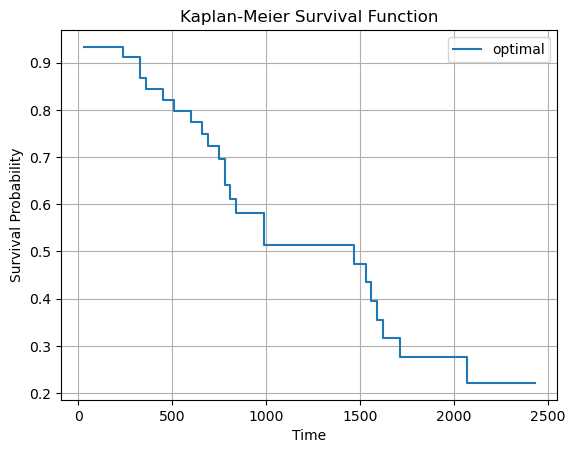

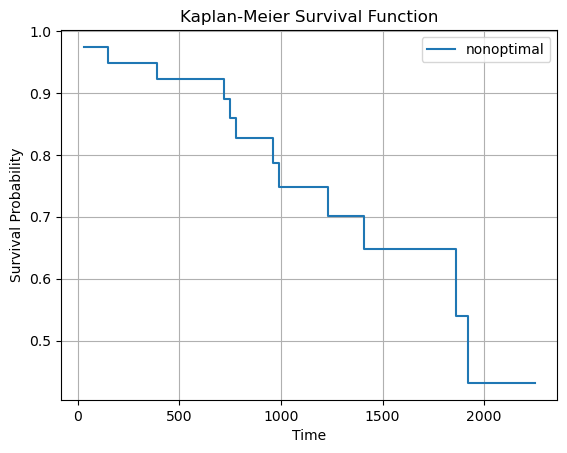

In [14]:
# Plot survival for tumor size ≥ 1 cm vs. tumor size < 1
predictor = 'debulk'
cat1 = 1
cat0 = 0
cat1_name = 'optimal'
cat0_name = 'nonoptimal'
plot_survival_twocat(df, predictor, cat1, cat0,cat1_name,cat0_name )

,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3,ANKRD27_binary
0,GSM432220,1650,0,0,-0.526989,1.305942,0.144564,0
1,GSM432221,30,1,1,-0.180496,1.286216,-0.455337,0
2,GSM432222,720,0,1,0.747367,-1.369031,0.626061,1
3,GSM432223,780,0,1,-0.425558,1.613270,0.458312,0
4,GSM432224,990,1,1,-0.476626,0.611514,-0.218782,0


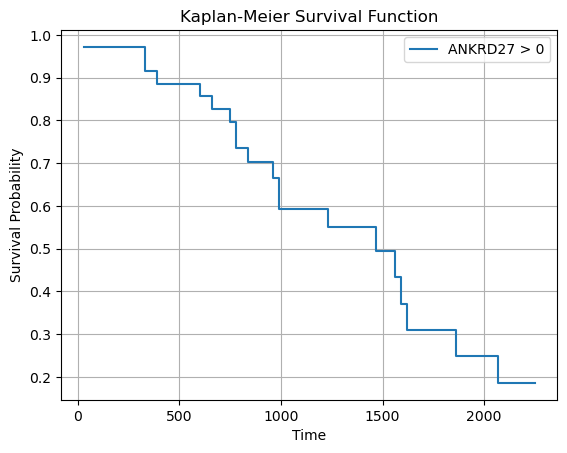

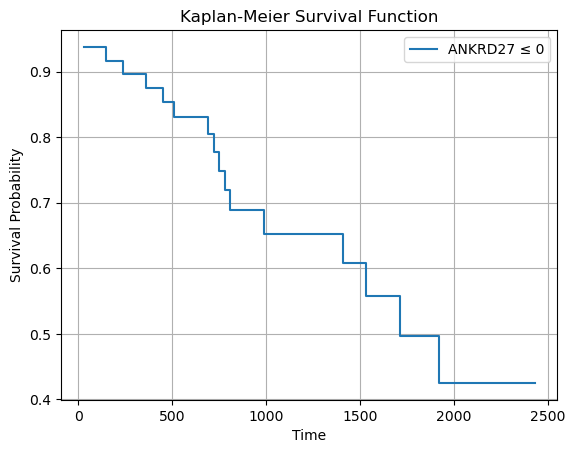

In [15]:
# Plot survival for ANKRD27 expression > 0 vs. ANKRD27 expression ≤ 0

# YOUR CODE GOES HERE

df["ANKRD27_binary"] = df["ANKRD27"].apply(lambda x: 1 if x > 0 else 0)
display(df.head())

predictor = 'ANKRD27_binary'
cat1 = 1
cat0 = 0
cat1_name = 'ANKRD27 > 0'
cat0_name = 'ANKRD27 ≤ 0'
plot_survival_twocat(df, predictor, cat1, cat0,cat1_name,cat0_name )


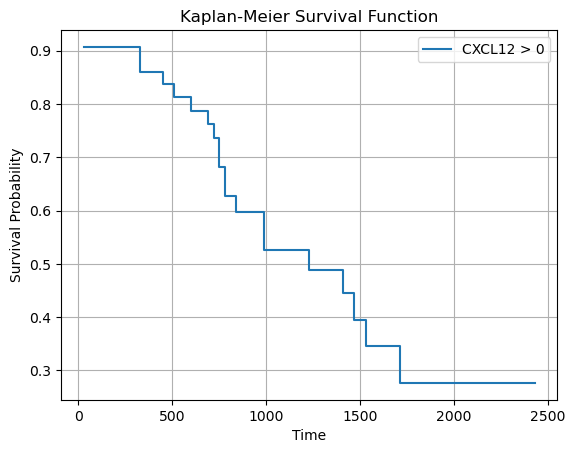

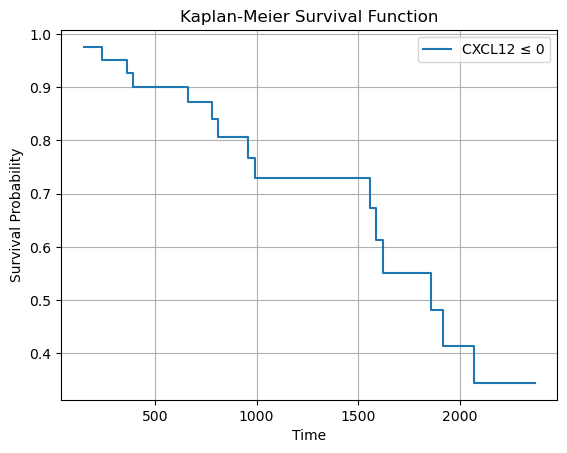

In [16]:
# Plot survival for CXCL12 expression > 0 vs. CXCL12 expression ≤ 0
df["CXCL12_binary"] = df["CXCL12"].apply(lambda x: 1 if x > 0 else 0)
predictor = 'CXCL12_binary'
cat1 = 1
cat0 = 0
cat1_name = 'CXCL12 > 0'
cat0_name = 'CXCL12 ≤ 0'
plot_survival_twocat(df, predictor, cat1, cat0,cat1_name,cat0_name )

# YOUR CODE GOES HERE

Which predictor above influences the survival probability in the first 500 days the least?

Answer:



In [17]:
# Answer:
# The predictor that appears to influence survival probability the least in the first 500 days is CXCL12 (CXCL12 > 0 vs CXCL12 ≤ 0).

# Reasoning:
# In the early-time window (0–500 days), the two Kaplan-Meier curves for CXCL12 are the most similar
# (smallest separation/overlap), while debulking status and ANKRD27 groups show larger early divergence.
# Smaller early divergence means weaker influence on short-term survival.

## TASK 8 (10 POINTS)
---
Plot the cumulative Hazard using the Nelson-Aalen estimator

In [18]:
# Plot the cumulative Hazard using the Nelson-Aalen estimator
def cumulative_hazard_NA(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
	"""
	Generates a dataframe containing the cumulative hazard  (H(t)) employing the
	Nelson-Aalen estimator.
	Inputs:
		df: input dataframe
		TimeColumn: name of the colum containing the event time
		EventColumn: name of the column indicating if the event happened or not
		EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
		EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for being alive
	Outputs:
		dfH: dataframe containing the time and Cumulative Hazard (H(t))
	"""

# Group the dataframe by the TimeColumn and calculate the number of events and number at risk at each time point
	df_grouped = df.sort_values(by=TimeColumn).groupby(TimeColumn)
	dfH = pd.DataFrame({TimeColumn: df_grouped[TimeColumn].first(), 'Cumulative_Hazard': np.zeros(len(df_grouped))})
	cumulative_hazard = 0.0

	previous_filtered_data = df
		
	for index, time in enumerate(dfH[TimeColumn]):
		if time < 0:
			raise ValueError("Time cannot be negative.")
		
		len_people_at_risk = len(df_grouped.get_group(time))
		
		len_people_event_happen = len(df_grouped.get_group(time)[df_grouped.get_group(time)[EventColumn] == EVENT_HAPPEN_INDICATOR])
  
		cumulative_hazard += len_people_event_happen / len_people_at_risk
  
		dfH.iloc[index, 1] = cumulative_hazard
  
      # YOUR CODE GOES HERE

	return dfH

def plot_cumH(df, TimeColumn, EventColumn, Name,EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR):
	"""
	This function plots the cumulative hazard of the whole df. This function calls
	calculate_hazard_NA.
	Inputs:
		df: input dataframe
		TimeColumn: name of the colum containing the event time
		EventColumn: name of the column indicating if the event happened (1) or not (0)
		Name: legend to display, associated to the CH
		EVENT_HAPPEN_INDICATOR: the indicator status when event happens, like 1 for death
		EVENT_NOT_HAPPEN_INDICATOR: the indicator status when event does not happen, like 0 for being alive
	"""
	
	dfH = cumulative_hazard_NA(df, TimeColumn, EventColumn, EVENT_HAPPEN_INDICATOR, EVENT_NOT_HAPPEN_INDICATOR)
	plt.step(dfH[TimeColumn], dfH['Cumulative_Hazard'], where="post", label=Name)
	plt.xlabel('Time')
	plt.ylabel('Cumulative Hazard')
	plt.title('Nelson-Aalen Cumulative Hazard Function')
	plt.legend()
	plt.grid()
	plt.show()
	
 

  # YOUR CODE GOES HERE

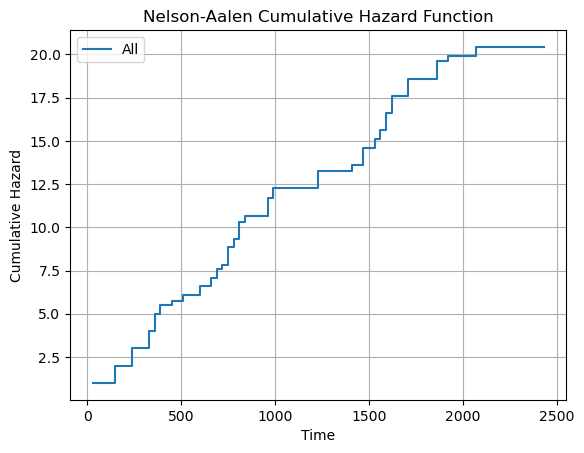

In [19]:
# Plot the cumulative hazard of df
TimeColumn='time'
EventColumn='death'
plot_cumH(df, TimeColumn, EventColumn, 'All', 1, 0)

# 2. Multivariate analysis
**Cox Proportional Hazards**

Now, we are going to employ multivariate analysis using CPH to determine the survival funtions and the hazard ratio of different patients.
We will employ [lifelines](https://lifelines.readthedocs.io/en/latest/index.html), a python survival analysis library. The relevant packages have been imported for you at the beginning.

## TASK 9 (5 POINTS)
---
Divide the dataframe into 80% training and 20% testing subsets and normalize the data.

In [20]:
#Divide the data into dfTrain 80% and dfTest 20%:
#And normalize the data
# YOUR CODE GOES HERE

dfTrain, dfTest = train_test_split(df, test_size=0.2, random_state=42)
print(f"Before Normalization:")
display(dfTrain.head())

# Normalize the data
scaler = StandardScaler()
predictor_columns = ['debulk', 'NCOA3', 'ANKRD27', 'CXCL12']
dfTrain[predictor_columns] = scaler.fit_transform(dfTrain[predictor_columns])
dfTest[predictor_columns] = scaler.transform(dfTest[predictor_columns])	
print(f"After normalization:")
display(dfTrain.head())



Before Normalization:


,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3,ANKRD27_binary,CXCL12_binary
76,GSM432321,1560,0,0,-1.224869,-0.288381,-0.122680,0,0
42,GSM432268,450,1,1,-0.085552,2.107385,0.838903,0,1
49,GSM432276,2160,0,1,2.687670,-0.154642,1.008368,1,0
11,GSM432232,810,1,1,-0.026619,-0.424468,-0.144819,0,0
30,GSM432254,930,0,1,-0.731636,-0.421189,-1.267898,0,0


After normalization:


,ID,time,death,debulk,ANKRD27,CXCL12,NCOA3,ANKRD27_binary,CXCL12_binary
76,GSM432321,1560,0,-1.045825,-1.120995,-0.367043,-0.177649,0,0
42,GSM432268,450,1,0.956183,-0.101018,1.924516,0.692752,0,1
49,GSM432276,2160,0,0.956183,2.381717,-0.239122,0.846148,1,0
11,GSM432232,810,1,0.956183,-0.048258,-0.497211,-0.197689,0,0
30,GSM432254,930,0,0.956183,-0.679427,-0.494075,-1.214274,0,0


## TASK 10 (5 POINTS)
---
Calculate and print the Cox proportional hazards coefficients of the training subset (dfTrain). As the data was normalized, the coefficients will provide information about the magnitude of the effect of each predictor variables. You can use CoxPHFitter from lifelines to do that.

In [21]:
# Calculate and print the Cox proportional hazards coefficients

# YOUR CODE GOES HERE
del dfTrain['ID']
print("Cox Proportional Hazards Coefficients:")
cph = CoxPHFitter().fit(dfTrain, duration_col=TimeColumn, event_col=EventColumn)



Cox Proportional Hazards Coefficients:


In [22]:
cph.print_summary()
cph.plot

<lifelines.CoxPHFitter: fitted with 67 total observations, 38 right-censored observations>
             duration col = 'time'
                event col = 'death'
      baseline estimation = breslow
   number of observations = 67
number of events observed = 29
   partial log-likelihood = -90.52
         time fit was run = 2026-03-24 11:06:40 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
debulk          0.55      1.74      0.24            0.08            1.02                1.08                2.78
ANKRD27        -0.40      0.67      0.29           -0.96            0.16                0.38                1.18
CXCL12         -0.68      0.51      0.40           -1.47            0.10                0.23                1.11
NCOA3           0.67      1.95      0.22            0.23            1.11                1.26                3.03
ANKRD27_binary  1.14      3.12      0.61           -0.06            2.34                0.94               10.36
CXCL12_binary   2.05      7.78      0.79            0.51            3.59                1.66               36.36

                cmp to     z      p  -log2(p)
covariate                                    
debulk            0.00  2.30   0.02      5.54
ANKRD27           0.00 -1.39   0.16      2.61
CXCL12            0.00 -1.71   0.09      3.50
NCOA3             0.00  2.99 <0.005      8.49
ANKRD27_binary    0.00  1.86   0.06      3.98
CXCL12_binary     0.00  2.61   0.01      6.77
---
Concordance = 0.74
Partial AIC = 193.04
log-likelihood ratio test = 21.55 on 6 df
-log2(p) of ll-ratio test = 9.42

<bound method SemiParametricPHFitter.plot of <lifelines.SemiParametricPHFitter: fitted with 67 total observations, 38 right-censored observations>>

In [23]:
cph.params_.values

array([ 0.55238106, -0.39957292, -0.68312138,  0.67011668,  1.13715135,
        2.05125524])

## TASK 11 (5 POINTS)
---
Plot the survival function of the three first participants in the test subset.

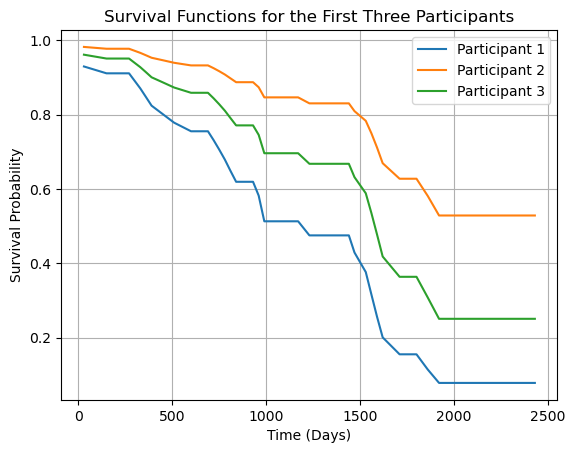

In [24]:
# Plot the survival function of the three first participants in the test subset
participant1 = 0
participant2 = 1
participant3 = 2

# 1. Group the participants into a list
participants = [participant1, participant2, participant3]

# 2. Predict the survival functions for all three at the same time
# Notice the double brackets for iloc if you were typing numbers directly: dfTest.iloc[[0, 1, 2]]
pl = cph.predict_survival_function(dfTest.iloc[participants])

# 3. Plot the combined dataframe
pl.plot()

# 4. Format the plot
plt.title("Survival Functions for the First Three Participants")
plt.xlabel('Time (Days)')
plt.ylabel('Survival Probability')
plt.grid()

# Optional: Add a legend so you know which line belongs to which patient
plt.legend(['Participant 1', 'Participant 2', 'Participant 3']) 

plt.show()

What is the most important property of CPH that you observe in the plot in terms of the shape of the three lines? (You can say more but we are looking for one key word)

Answer:

**Proportional hazards** - the three CPH survival curves tend to keep a similar shape over time (often roughly parallel / non-crossing), reflecting a time-constant hazard ratio.

## TASK 12 (10 POINTS)
---
Create a function that calculates the hazard ratio between two patients. This tells us which one of the two patients is at a higher risk.

In [25]:
# Create a function that calculates the hazard ratio between two patients.
# This will tell us which patient is at a higher risk.
def hazard_ratio(df, participant1, participant2, cph):
	'''
	Calculates the hazard ratio of participant1 vs participant 2 using
	the coefficients of the CPH model.

	Inputs:
		df: dataframe containing all the participants of the study subset
		participant1: index of the first participant in the df.
		participant2: index of the second participant in the df.
		cph: CPH model obtained with lifelines
	Outputs:
		HR: hazard ratio of participant 1 vs participant 2
	'''

	df_participants = df.iloc[[participant1, participant2]]
	HR = cph.predict_partial_hazard(df_participants).values
	print(HR)
	HR = HR[0] / HR[1]  # Hazard ratio of participant

    # YOUR CODE GOES HERE

	return HR

In [26]:
print('Participant 1 vs participant 2 Hazard Ratio: ' + str(hazard_ratio(dfTest, 5, 10, cph)))

[0.48576343 1.01756368]
Participant 1 vs participant 2 Hazard Ratio: 0.4773789005895428


## TASK 13 (15 POINTS)
---
Create a function to calculate the concordance index of the CPH model you just trained, using the test data.

In [27]:
# concordance index function
def c_index_mlma(df, TimeColumn, EventColumn, cph):
    '''
    Computes the C-Index employing the testing data and trained models.
    '''
    concordant_pairs: int = 0
    tied_pairs: int = 0
    total_pairs: int = 0
    
    risks = cph.predict_partial_hazard(df).values.flatten()
    y_true = df[TimeColumn].values
    event = df[EventColumn].values
 
    # Loop over all possible pairs of participants
    for i in range(len(df)):
        for j in range(i + 1, len(df)): 
            time_i = y_true[i]
            time_j = y_true[j]
            event_i = event[i]
            event_j = event[j]
            risk_i = risks[i]
            risk_j = risks[j]

            # FIX 1: Skip identical times immediately
            if time_i == time_j:
                continue
 
            # Skip if both patients are censored
            if event_i == 0 and event_j == 0:
                continue
            
            # Scenario A: Both patients died
            if event_i == 1 and event_j == 1:
                total_pairs += 1
                
                if (time_i < time_j and risk_i > risk_j) or (time_j < time_i and risk_j > risk_i):
                    concordant_pairs += 1
                elif risk_i == risk_j:
                    tied_pairs += 1
                    
            # Scenario B: i died, j was censored
            if event_i == 1 and event_j == 0:
                # First, check if the pair is valid
                if time_i < time_j:
                    total_pairs += 1 # It is a valid pair, so count it!
                    
                    # Next, check if the model was right, wrong, or tied
                    if risk_i > risk_j:
                        concordant_pairs += 1
                    elif risk_i == risk_j:
                        tied_pairs += 1
                    
            # Scenario C: j died, i was censored
            if event_i == 0 and event_j == 1:
                # First, check if the pair is valid
                if time_j < time_i:
                    total_pairs += 1 # It is a valid pair, so count it!
                    
                    # Next, check if the model was right, wrong, or tied
                    if risk_j > risk_i:
                        concordant_pairs += 1
                    elif risk_j == risk_i:
                        tied_pairs += 1
 
    CI = ((concordant_pairs + 0.5 * tied_pairs) / total_pairs) if total_pairs > 0 else 0
    return CI

In [28]:
# Concordance Index of the training data
display(dfTrain.head())
TimeColumn='time'
EventColumn='death'
CI=c_index_mlma(dfTrain, TimeColumn, EventColumn, cph)
print(CI)

,time,death,debulk,ANKRD27,CXCL12,NCOA3,ANKRD27_binary,CXCL12_binary
76,1560,0,-1.045825,-1.120995,-0.367043,-0.177649,0,0
42,450,1,0.956183,-0.101018,1.924516,0.692752,0,1
49,2160,0,0.956183,2.381717,-0.239122,0.846148,1,0
11,810,1,0.956183,-0.048258,-0.497211,-0.197689,0,0
30,930,0,0.956183,-0.679427,-0.494075,-1.214274,0,0


0.7342465753424657


In [29]:
# Your output above be similar to the CI calculated by the lifelines library (+/- 0.015)
print(cph.concordance_index_)

0.7369838420107719


In [30]:
# Concordance Index of the testing data

# YOUR CODE GOES HERE
c_index_mlma(dfTest, TimeColumn, EventColumn, cph)

0.5555555555555556

# Survival Trees

Now, we are going to use a different type of multivariate analysis to calculate survival functions: ExtraSurvivalTrees. To perform this type of analysis, we will employ the [scikit-survival library](https://scikit-survival.readthedocs.io/en/stable/index.html).


## TASK 14 (5 POINTS)
---
Train a estimator using the training subset .

In [31]:
# convert_data_survival function
def convert_data_survival(df):
    '''
    Preprocesses a DataFrame for survival analysis by
    applying one-hot encoding to categorical features (excluding 'time' and 'death')
    and then formats the 'death' (as boolean) and 'time' columns into
    a structured NumPy record array

    Inputs:
        df: Input DataFrame with survival data.

    Outputs:
        X: A DataFrame with one-hot encoded features.
        y: A structured array containing death as boolean and time.
    '''

    # YOUR CODE GOES HERE

    # 1. Separate features
    X = df.drop(columns=['time', 'death'])

    # 2. One-hot encode using sksurv encoder
    encoder = OneHotEncoder()
    X = encoder.fit_transform(X)

    # 3. Create structured survival array manually (since Surv is NOT imported)
    y = np.array(
        [(bool(event), float(time)) for event, time in zip(df['death'], df['time'])],
        dtype=[('event', '?'), ('time', '<f8')]
    )

    return X, y

In [36]:
dfTest = dfTest.drop(columns=['ID'])  # Drop ID column if it exists
display(dfTest.head())
X_train, Y_train=convert_data_survival(dfTrain)
X_test,  Y_test=convert_data_survival(dfTest)

,time,death,debulk,ANKRD27,CXCL12,NCOA3,ANKRD27_binary,CXCL12_binary
73,780,1,-1.045825,0.130957,0.444560,0.081478,1,1
0,1650,0,-1.045825,-0.496216,1.157932,0.064253,0,1
58,750,1,-1.045825,-1.164039,0.728912,0.384714,0,1
22,2220,0,-1.045825,-1.303286,0.827594,-0.916703,0,1
12,2070,1,0.956183,0.178979,-0.808343,0.787076,1,0


In [37]:
estimator = ExtraSurvivalTrees().fit(X_train, Y_train)
estimator

,n_estimators,100
,max_depth,None
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,None
,random_state,None


## TASK 15 (5 POINTS)
---
Calculate the CI of the model when applied to the testing subset. Use the scikit-survival scoring functions to obtain the index. Compare this result with the CI obtained with the CPH models.

In [38]:
# YOUR CODE GOES HERE
# 
from sksurv.metrics import concordance_index_censored
display(X_test.head())
risk_scores = estimator.predict(X_test)
ci_tree = concordance_index_censored(
    Y_test['event'],
    Y_test['time'],
    risk_scores
)[0]
print("C-index (Survival Trees):", ci_tree)
# Start by converting the data using the convert_data_survival function

,debulk,ANKRD27,CXCL12,NCOA3,ANKRD27_binary,CXCL12_binary
73,-1.045825,0.130957,0.444560,0.081478,1,1
0,-1.045825,-0.496216,1.157932,0.064253,0,1
58,-1.045825,-1.164039,0.728912,0.384714,0,1
22,-1.045825,-1.303286,0.827594,-0.916703,0,1
12,0.956183,0.178979,-0.808343,0.787076,1,0


C-index (Survival Trees): 0.547945205479452


In [ ]:
cph = CoxPHFitter()
df_train_cph = dfTrain.copy()

cph.fit(df_train_cph, duration_col='time', event_col='death')

df_test_cph = dfTest.copy()

risk_scores_cph = cph.predict_partial_hazard(df_test_cph)
ci_cph = concordance_index_censored(
    df_test_cph['death'].astype(bool),
    df_test_cph['time'],
    risk_scores_cph
)[0]
print("C-index (Survival Trees):", ci_tree)
print("C-index (Cox PH):", ci_cph)

C-index (Survival Trees): 0.547945205479452
C-index (Cox PH): 0.5616438356164384


Answer:

The most important property of the Cox Proportional Hazard is that it is not a step function but rather continous and makes inference in time events that are not seen in the dataset.

## TASK 16 (5 POINTS)
---
Calculate the survival function of the three first patients in the testing subset. Compare these survival functions with those obtained with the CPH models.

In [ ]:
## Plot the survival function for the three first patients in the testing subset
X_test_sel=X_test.iloc[1:4,:]

# YOUR CODE GOES HERE

What property do you observe, compared to the plot of the CPH above, in terms of the shape of the three lines?

Answer:

## TASK 17 (4 POINTS)
---
Please answer the questions below

In TASK 4, we split the dataset into two subsets for training (80%) and testing (20%). Considering the size of the dataset we use in this lab, do you think this split is a good choice？ What method or methods we could take into consideration when the dataset is too small for implementing this split?

Answer:

# TASK 18 (15 POINTS)
---
Using the decision tree code that you created in Lab 1 as a base, create your own Survival Tree algorithm, using the splitting criterion of your choice (you can use Logrank statistic or likelihood ratio statistic, as indicated in the course's slides). The algorithm should include the same hyper-parameters from Lab 1 and also min_obs_leaf, which indicates the minimum number of observations that a leaf should have. Use the training subset to train a survival tree and represent the survival functions on the three first patients from the testing subset.

In [ ]:
# YOUR CODE GOES HERE

# TASK 19 (10 POINTS) (Bonus)
---
Reimplement the survival tree algorithm from Task 18 using a different method for the splitting criteria.

In [ ]:
# YOUR CODE GOES HERE

What is a benefit of your new splitting criteria compared to the one you previously used?

Answer:


What is a drawback of your new splitting criteria compared to the one you previously used?

Answer:

## TASK 20
---
Run the following cell to finish the lab.

In [ ]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/WwJPoL5FLF8" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>')

: 

Paste your colab link here:

**You are ready to submit in Gradescope!**

Please suffix your colab file with _\<JHED ID\> (It's the part before the @ symbol in your email)

e.g. Lab1_Decision_trees_myjhedID

4 easy steps to submit your lab:

1.   Click on "Share" option on top right - Click on "copy link" option. Make sure your permission is set to "Anyone on the internet with this link can view". And paste it in the cell above.
2.   Go to "File" - "Download .ipynb" and "Download .py".
3.   Export the notebook to a PDF file with all the outputs.
3.   Upload the three files (.pdf, .ipynb, .py) to Gradescope.

That's it!